In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import classification_report


In [ ]:
# read the cleaned csv file
gym_df = pd.read_csv('data/processed/rutgers_gym_cleaned.csv')

# analyze the data
gym_df.head()
print(gym_df.columns.tolist())

['gym_name', 'day_of_week', 'hour', 'busyness_percent', 'hour_24', 'is_weekend', 'semester_week', 'is_exam_week', 'weather', 'capacity_label']


In [28]:
# initialize the label encoder
gym_encoder = LabelEncoder()
day_encoder = LabelEncoder()
weather_encoder = LabelEncoder()
capacity_encoder = LabelEncoder()


# convert gym names into numbers 
gym_df['gym_name_encoded'] = gym_encoder.fit_transform(gym_df['gym_name'])

# convert day names into numbers 
gym_df['day_of_week_encoded'] = day_encoder.fit_transform(gym_df['day_of_week'])

# convert weathers into numbers 
gym_df['weather_encoded'] = weather_encoder.fit_transform(gym_df['weather'])

# convert capacity into numbers -> target 
gym_df['capacity_label_encoded'] = capacity_encoder.fit_transform(gym_df['capacity_label'])

# check if encoding worked
print(gym_df[['gym_name', 'gym_name_encoded', 'day_of_week', 'day_of_week_encoded', 'capacity_label', 'capacity_label_encoded']].head())


             gym_name  gym_name_encoded day_of_week  day_of_week_encoded  \
0  College Avenue Gym                 0      Monday                    1   
1  College Avenue Gym                 0      Monday                    1   
2  College Avenue Gym                 0      Monday                    1   
3  College Avenue Gym                 0      Monday                    1   
4  College Avenue Gym                 0      Monday                    1   

  capacity_label  capacity_label_encoded  
0            Low                       1  
1            Low                       1  
2            Low                       1  
3            Low                       1  
4            Low                       1  


In [29]:
# select columns as features for the model
features = [
    'gym_name_encoded',
    'day_of_week_encoded',
    'hour_24',
    'is_weekend',
    'semester_week',
    'is_exam_week',
    'weather_encoded'
]

# define X for the input
X = gym_df[features]

# define y for the target and display the shapes for each
y = gym_df['capacity_label_encoded']

print('Input shape:', X.shape)
print('Target shape:', y.shape)

Input shape: (331, 7)
Target shape: (331,)


In [30]:
# split data training:testing -> 80%:20%
# random_state=42 ensures consistent result every run
# display the rows for training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 264
Testing rows: 67


In [31]:
# initialize Random Forest
# n_estimators=100 -> 100 decision trees and votes on result
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# train model on test data
rf_model.fit(X_train, y_train)

print('Model trained successfully')


Model trained successfully


In [32]:
# use the trained model to predict test data
y_pred = rf_model.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# calculate MAE (average diff between pred. and actual)
mae = mean_absolute_error(y_test, y_pred)

# calculate RMSE 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('Accuracy:', round(accuracy * 100, 2), '%')
print('MAE:', round(mae, 3))
print('RMSE:', round(rmse, 3))

Accuracy: 76.12 %
MAE: 0.358
RMSE: 0.773


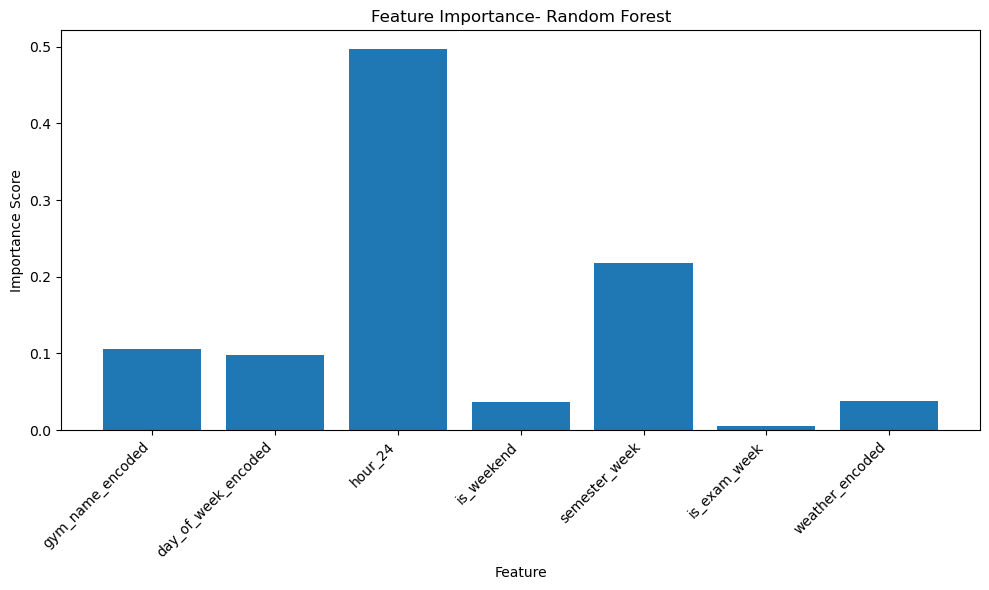

In [33]:
# feature importance scores from model
importances = rf_model.feature_importances_

# plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(features, importances)

# title and labels
plt.title('Feature Importance- Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance Score')

# emove overlapping with x-axis 
plt.xticks(rotation=45, ha='right')

# space adjustment
plt.tight_layout()

# display the plot
plt.show()

In [34]:
# prediction function to predict the capacity of a gym
def predict_capacity(gym_name, day_of_week, hour_24, is_weekend, semester_week, is_exam_week, weather):
    #use encoders to convert from text to numbers
    gym_encoded = gym_encoder.transform([gym_name])[0]
    day_encoded = day_encoder.transform([day_of_week])[0]
    weather_encoded = weather_encoder.transform([weather])[0]

    #input array in same order as features
    input_data = [[gym_encoded, day_encoded, hour_24, is_weekend, semester_week, is_exam_week, weather_encoded]]

    #make prediction
    prediction_encoded = rf_model.predict(input_data)[0]

    #convert prediction number into label
    prediction_label = capacity_encoder.inverse_transform([prediction_encoded])[0]

    return prediction_label

In [35]:
# user enters their info, then gets result for capacity level 
def get_user_prediction():
    
    print("=== Rutgers Gym Capacity Predictor ===\n")
    
    # Valid options
    valid_gyms = sorted(gym_df['gym_name'].unique())
    valid_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    valid_weather = ['clear', 'rain']
    
    try:
        # Gym input
        print("Available gyms:")
        for i, gym in enumerate(valid_gyms):
            print(f"  {i+1}. {gym}")
        gym_name = input("\nEnter gym name exactly as shown: ").strip()
        if gym_name not in valid_gyms:
            raise ValueError(f"'{gym_name}' is not a valid gym. Please copy it exactly as shown.")
        
        # Day input
        print("\nAvailable days: Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, Sunday")
        day_of_week = input("Enter day: ").strip().title()
        if day_of_week not in valid_days:
            raise ValueError(f"'{day_of_week}' is not a valid day. Use full day name e.g. Monday.")
        
        # Hour input
        hour_24 = int(input("\nEnter hour (0-23, e.g. 14 for 2pm): ").strip())
        if hour_24 < 0 or hour_24 > 23:
            raise ValueError("Hour must be between 0 and 23.")
        
        # Auto calculate is_weekend
        is_weekend = 1 if day_of_week in ['Saturday', 'Sunday'] else 0
        
        # Semester week input
        semester_week = int(input("\nEnter semester week (1-15): ").strip())
        if semester_week < 1 or semester_week > 15:
            raise ValueError("Semester week must be between 1 and 15.")
        
        # Auto calculate is_exam_week
        is_exam_week = 1 if semester_week >= 14 else 0
        
        # Weather input
        print("\nWeather options: clear, rain")
        weather = input("Enter weather: ").strip().lower()
        if weather not in valid_weather:
            raise ValueError(f"'{weather}' is not valid. Choose either 'clear' or 'rain'.")
        
        # Make prediction
        result = predict_capacity(gym_name, day_of_week, hour_24, is_weekend, semester_week, is_exam_week, weather)
        
        # Display result
        print(f"\n📍 Gym: {gym_name}")
        print(f"📅 {day_of_week} at {hour_24}:00")
        print(f"🏋️ Predicted Capacity: {result}")
        
        if result == "Low":
            print("✅ Great time to go!")
        elif result == "Medium":
            print("⚠️  Moderate — might be somewhat busy")
        else:
            print("❌ Bad time — expect it to be packed")
    
    except ValueError as e:
        print(f"\n❌ Input Error: {e}")
        print("Please re-run the cell and try again.")
    except Exception as e:
        print(f"\n❌ Unexpected error: {e}")
        print("Please re-run the cell and try again.")

# Run the predictor
get_user_prediction()

=== Rutgers Gym Capacity Predictor ===

Available gyms:
  1. College Avenue Gym
  2. Cook/Douglass Recreation Center
  3. Livingston Recreation Center
  4. Sonny Werblin Recreation Center

Available days: Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, Sunday

Weather options: clear, rain

📍 Gym: College Avenue Gym
📅 Monday at 4:00
🏋️ Predicted Capacity: Low
✅ Great time to go!


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


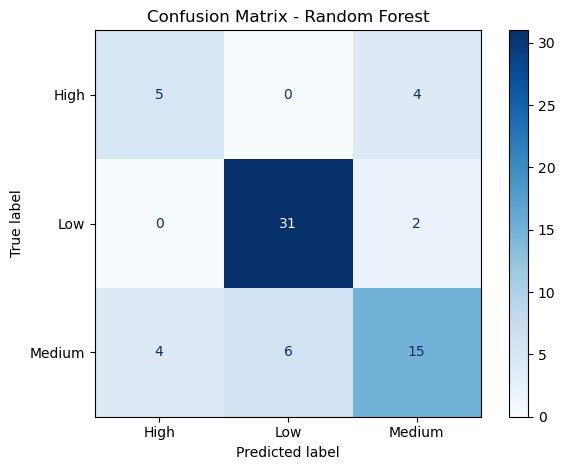

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

# create the confusion matrix 
cm = confusion_matrix(y_test, y_pred)

# get capacity labels in the right order
labels = capacity_encoder.inverse_transform([0, 1, 2])

# display the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

In [38]:
# Generate full classification report in correct order
capacity_order = ['Low', 'Medium', 'High']

# Get the encoded values for each label in the correct order
ordered_labels = [list(capacity_encoder.classes_).index(label) for label in capacity_order]

print(classification_report(
    y_test,
    y_pred,
    labels=ordered_labels,
    target_names=capacity_order
))

              precision    recall  f1-score   support

        High       0.56      0.56      0.56         9
         Low       0.84      0.94      0.89        33
      Medium       0.71      0.60      0.65        25

    accuracy                           0.76        67
   macro avg       0.70      0.70      0.70        67
weighted avg       0.75      0.76      0.75        67

